# Data Preparation

prepare the PIE dataset and our own selfies for the face recognition task.

**Steps:**
1. Load configuration and set random seed
2. Randomly select 25 subjects from 68 available subjects
3. Load and preprocess PIE dataset images
4. Load and preprocess selfie images
5. Split data into training (70%) and testing (30%) sets
6. Combine PIE and selfie data for final dataset

In [1]:
import os
import sys
import random
import numpy as np
import traceback
from pathlib import Path
from matplotlib import pyplot as plt

sys.path.append(str(Path().absolute().parent))

from src.data.data_loader import load_config, select_random_subjects, prepare_dataset

## Load Configuration and Set Seed

In [2]:
try:
    config = load_config()
    print(f"Using seed value: {config['seed']}")
    random.seed(config['seed'])
    np.random.seed(config['seed'])
except Exception as e:
    print(f"Error loading configuration: {e}")
    print(traceback.format_exc(limit=3))

Using seed value: 963


## Select Random Subjects

In [3]:
try:
    selected_subjects = select_random_subjects()
    print(f"Selected {len(selected_subjects)} subjects: {selected_subjects}")
    
	#add the selfie class index
    selected_subjects.append(26)
    print(f"Final subject list with selfie class: {selected_subjects}")
    
except Exception as e:
    print(f"Error selecting subjects: {e}")
    print(traceback.format_exc(limit=3))

Selected 25 subjects: [3, 5, 8, 10, 12, 13, 17, 19, 20, 21, 22, 28, 30, 37, 39, 41, 42, 44, 46, 47, 48, 50, 51, 52, 57]
Final subject list with selfie class: [3, 5, 8, 10, 12, 13, 17, 19, 20, 21, 22, 28, 30, 37, 39, 41, 42, 44, 46, 47, 48, 50, 51, 52, 57, 26]


In [4]:
import json
with open("../Outputsselected_subjects.json", "w") as f:
	json.dump(selected_subjects, f)

## Prepare Dataset

In [5]:
try:
    cmupie_dir = "../PIE"
    selfie_dir = "../Selfies and Images"
    
    x_train, x_test, y_train, y_test, valid_subjects, train_selfie_indices, test_selfie_indices = prepare_dataset(
        cmupie_dir, selfie_dir
    )
    
    print(f"Dataset preparation completed:")
    print(f"Training samples: {x_train.shape[0]} | Test samples: {x_test.shape[0]}")
    print(f"Image feature dimension: {x_train.shape[1]} | Number of classes: {len(np.unique(y_train))}")
    print(f"Selfie samples in training: {len(train_selfie_indices)} | Selfie samples in test: {len(test_selfie_indices)}")
    
except Exception as e:
    print(f"Error during dataset preparation: {e}")
    print(traceback.format_exc(limit=3))

Selected subjects: [1, 2, 10, 11, 12, 20, 23, 25, 26, 33, 34, 36, 38, 43, 46, 47, 48, 49, 51, 52, 56, 58, 60, 61, 63]
Selected 7 subjects from the selfie dataset for training.
Dataset preparation completed:
Training samples: 2978 | Test samples: 1276
Image feature dimension: 1024 | Number of classes: 25
Selfie samples in training: 7 | Selfie samples in test: 3


## Visualize Sample Images

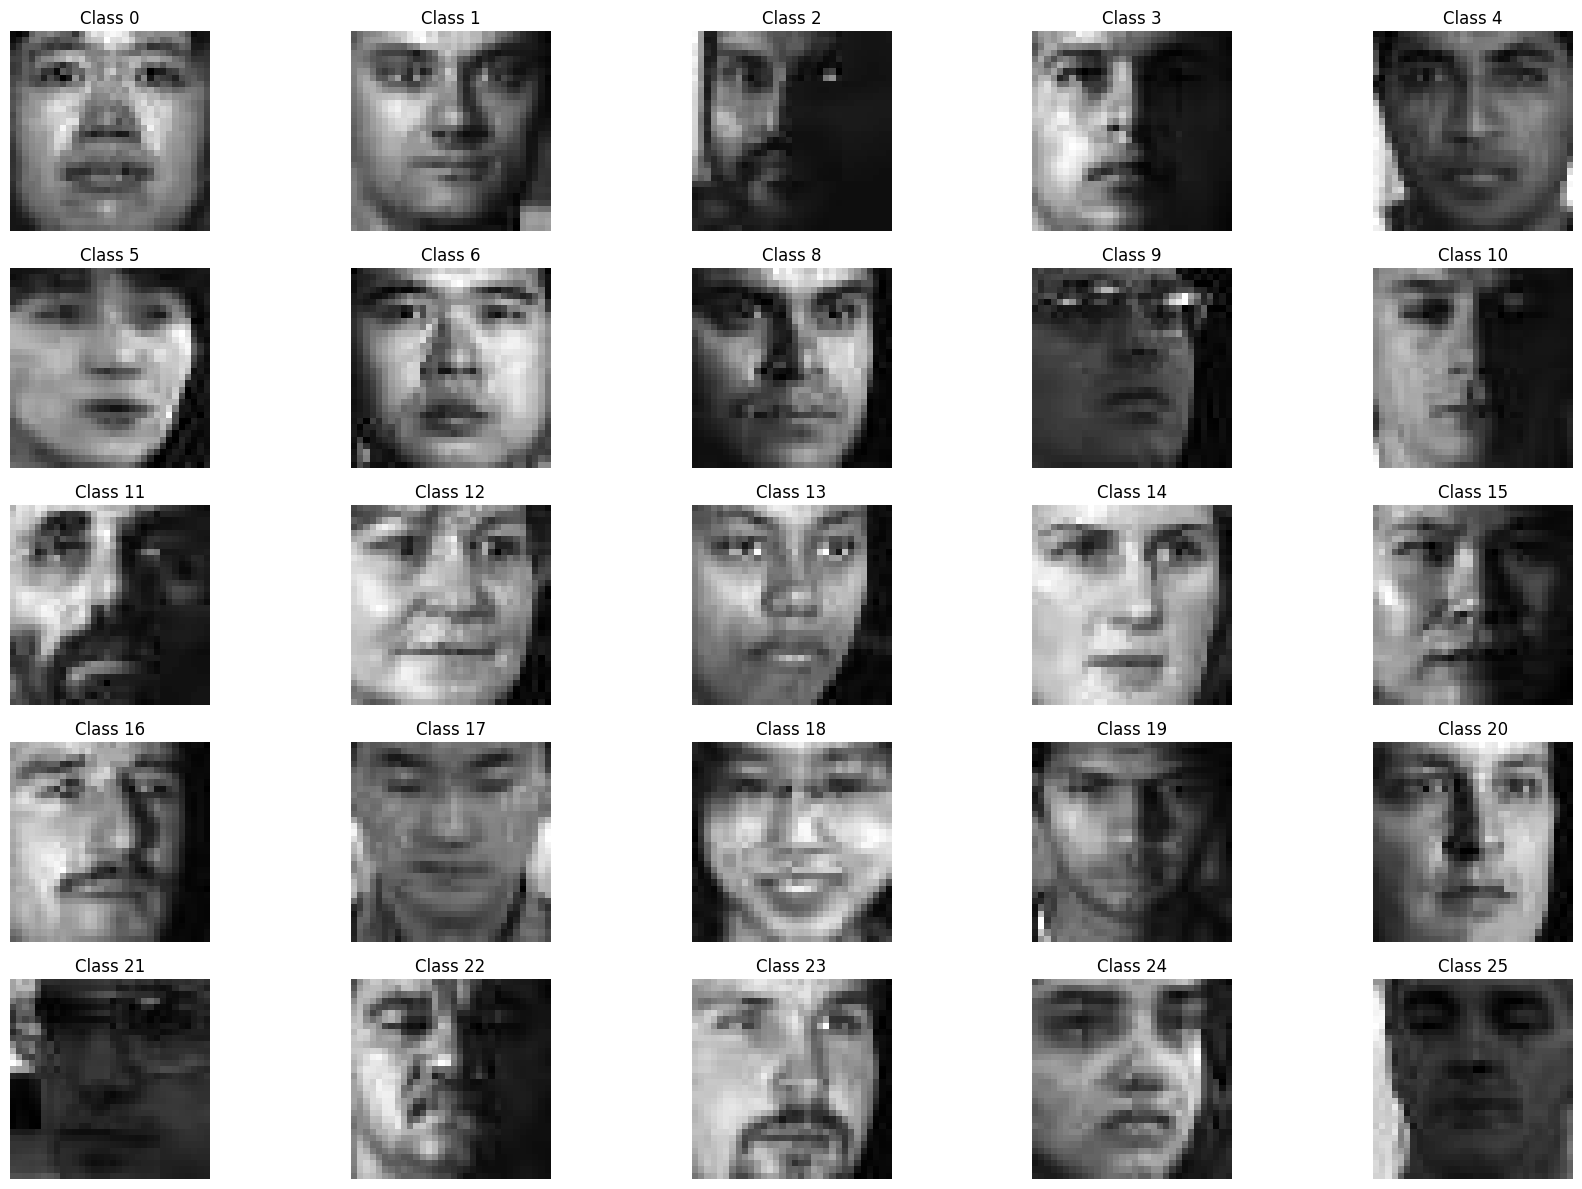

In [6]:
try:
    if x_train is not None:
        #display first few images from different classes
        unique_classes = np.unique(y_train)
        fig, axes = plt.subplots(5, 5, figsize=(18, 12))
        
        for i, class_label in enumerate(unique_classes):
            class_indices = np.where(y_train == class_label)[0]
            sample_idx = class_indices[0]
            
            #reshape back to 32x32 for visualization
            img = x_train[sample_idx].reshape(32, 32)
            
            row, col = i // 5, i % 5
            axes[row, col].imshow(img, cmap='gray')
            axes[row, col].set_title(f'Class {class_label}')
            axes[row, col].axis('off')
            
            #highlight selfie images
            if sample_idx in train_selfie_indices:
                axes[row, col].set_title(f'Class {class_label} (Selfie)', color='red')
        
        plt.tight_layout()
        plt.show()
    
except Exception as e:
    print(f"Error visualizing images: {e}")
    print(traceback.format_exc(limit=3))

## Save Processed Data

In [7]:
os.makedirs('../Outputs/data', exist_ok=True)
try:

    if x_train is not None:
        # Save processed data for later use
        np.save('../Outputs/data/x_train.npy', x_train)
        np.save('../Outputs/data/x_test.npy', x_test)
        np.save('../Outputs/data/y_train.npy', y_train)
        np.save('../Outputs/data/y_test.npy', y_test)
        np.save('../Outputs/data/train_selfie_indices.npy', train_selfie_indices)
        np.save('../Outputs/data/test_selfie_indices.npy', test_selfie_indices)
        np.save('../Outputs/data/valid_subjects.npy', valid_subjects)
        
        print("Processed data saved to Outputs/data/")
    
except Exception as e:
    print(f"Error saving data: {e}")
    print(traceback.format_exc(limit=3))

Processed data saved to Outputs/data/
